# Detecting Outliers

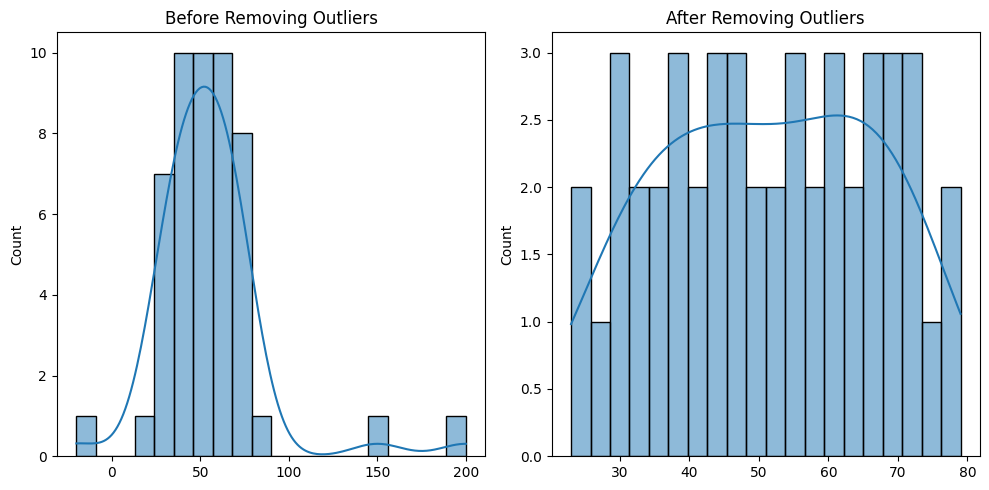

In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

arr = np.array([
23,25,27,29,30,31,33,34,35,36,
37,38,39,40,42,43,44,45,46,47,
48,49,50,52,53,54,55,56,58,59,
60,61,62,63,64,65,66,67,68,69,
70,71,72,73,75,77,79,150,-20,200
])

q1 = np.percentile(arr,25) # Q1
q3 = np.percentile(arr,75) # Q3

iqr = q3 - q1 # Inter Quartile Range

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

new_array = arr[(arr >= lower) & (arr <= upper)]
print(new_array) # No Outliers

fig, ax = plt.subplots(1,2,figsize=(10,5))

sns.histplot(arr,bins=20,kde=True,ax=ax[0])
ax[0].set_title("Before Removing Outliers")

sns.histplot(new_array,bins=20,kde=True,ax=ax[1])
ax[1].set_title("After Removing Outliers")

plt.tight_layout()
plt.show()

# Z test

In [1]:
import numpy as np
from scipy.stats import norm

def z_test(sample, population_mean, population_std, alpha=0.05, tail='two'):
    n = len(sample)

    if n < 30:
        print("Warning: Sample size < 30")


    # z score = (sample_mean-population_mean)/(population_std)/sqrt(n(sample_data))
    
    sample_mean = np.mean(sample)
    standard_error = population_std / np.sqrt(n)
    z_score = (sample_mean - population_mean) / standard_error

    if tail == 'two':
        p_value = 2 * (1 - norm.cdf(abs(z_score)))
    elif tail == 'right':
        p_value = 1 - norm.cdf(z_score)
    elif tail == 'left':
        p_value = norm.cdf(z_score)
    else:
        raise ValueError("tail must be 'two', 'right', or 'left'")

    print("\n===== Z-Test Results =====")
    print("Sample Size:", n)
    print("Sample Mean:", round(sample_mean, 4))
    print("Population Mean:", population_mean)
    print("Population Std Dev:", population_std)
    print("Standard Error:", round(standard_error, 4))
    print("Z-Score:", round(z_score, 4))
    print("P-Value:", round(p_value, 6))
    print("Alpha:", alpha)

    if p_value < alpha:
        print("Decision: Reject the null hypothesis")
    else:
        print("Decision: Fail to reject the null hypothesis")

    return z_score, p_value


np.random.seed(42)
sample_data = np.random.normal(loc=172, scale=3, size=35) #random distribution function with mean 172 ,std 3,size 35 numbers

z_test(sample_data, population_mean=170, population_std=3, alpha=0.05, tail='two')
z_test(sample_data, population_mean=168, population_std=3, alpha=0.05, tail='right')
z_test(sample_data, population_mean=175, population_std=3, alpha=0.05, tail='left')


===== Z-Test Results =====
Sample Size: 35
Sample Mean: 171.6021
Population Mean: 170
Population Std Dev: 3
Standard Error: 0.5071
Z-Score: 3.1593
P-Value: 0.001581
Alpha: 0.05
Decision: Reject the null hypothesis

===== Z-Test Results =====
Sample Size: 35
Sample Mean: 171.6021
Population Mean: 168
Population Std Dev: 3
Standard Error: 0.5071
Z-Score: 7.1034
P-Value: 0.0
Alpha: 0.05
Decision: Reject the null hypothesis

===== Z-Test Results =====
Sample Size: 35
Sample Mean: 171.6021
Population Mean: 175
Population Std Dev: 3
Standard Error: 0.5071
Z-Score: -6.7008
P-Value: 0.0
Alpha: 0.05
Decision: Reject the null hypothesis


(np.float64(-6.700805262648455), np.float64(1.0363705708082167e-11))

# T Test

In [2]:
import numpy as np
from scipy.stats import t

def t_test(sample, population_mean, alpha=0.05, tail='two'):
    n = len(sample)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1) # ddof = degree of freedom
    standard_error = sample_std / np.sqrt(n)
    t_score = (sample_mean - population_mean) / standard_error
    df = n - 1

    if tail == 'two':
        p_value = 2 * (1 - t.cdf(abs(t_score), df))
    elif tail == 'right':
        p_value = 1 - t.cdf(t_score, df)
    elif tail == 'left':
        p_value = t.cdf(t_score, df)
    else:
        raise ValueError("tail must be 'two', 'right', or 'left'")

    print("\n===== T-Test Results =====")
    print("Sample Size:", n)
    print("Sample Mean:", round(sample_mean, 4))
    print("Sample Std Dev:", round(sample_std, 4))
    print("Degrees of Freedom:", df)
    print("T-Score:", round(t_score, 4))
    print("P-Value:", round(p_value, 6))
    print("Alpha:", alpha)

    if p_value < alpha:
        print("Decision: Reject the null hypothesis")
    else:
        print("Decision: Fail to reject the null hypothesis")

    return t_score, p_value


np.random.seed(10)
sample_data = np.random.normal(loc=72, scale=5, size=20)

t_test(sample_data, population_mean=70, alpha=0.05, tail='two')
t_test(sample_data, population_mean=68, alpha=0.05, tail='right')
t_test(sample_data, population_mean=75, alpha=0.05, tail='left')


===== T-Test Results =====
Sample Size: 20
Sample Mean: 72.5936
Sample Std Dev: 4.2862
Degrees of Freedom: 19
T-Score: 2.7061
P-Value: 0.014004
Alpha: 0.05
Decision: Reject the null hypothesis

===== T-Test Results =====
Sample Size: 20
Sample Mean: 72.5936
Sample Std Dev: 4.2862
Degrees of Freedom: 19
T-Score: 4.7929
P-Value: 6.3e-05
Alpha: 0.05
Decision: Reject the null hypothesis

===== T-Test Results =====
Sample Size: 20
Sample Mean: 72.5936
Sample Std Dev: 4.2862
Degrees of Freedom: 19
T-Score: -2.5108
P-Value: 0.010626
Alpha: 0.05
Decision: Reject the null hypothesis


(np.float64(-2.510784268922245), np.float64(0.010625705551223422))

# Two Sample T Test

In [3]:
import numpy as np
from scipy import stats

# Create two independent samples
sample1 = np.array([10, 12, 14, 16, 18])
sample2 = np.array([8, 9, 11, 13, 15])

# Perform independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(sample1, sample2,equal_var=False)

# Print results
print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis (Means are significantly different)")
else:
    print("Fail to Reject Null Hypothesis (No significant difference)")

T-Statistic: 1.467598771410686
P-Value: 0.1807571489450302
Fail to Reject Null Hypothesis (No significant difference)


# Chi Square Test

In [4]:
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
import pandas as pd

In [5]:
np.random.seed(42)

n = 100   # number of passengers

# Randomly Generated data based on titanic dataset in seaborn
data = {
    "survived": np.random.choice([0, 1], n, p=[0.6, 0.4]),
    "pclass": np.random.choice([1, 2, 3], n, p=[0.2, 0.3, 0.5]),
    "sex": np.random.choice(["male", "female"], n),
    "age": np.random.randint(1, 80, n),
    "sibsp": np.random.randint(0, 5, n),
    "parch": np.random.randint(0, 5, n),
    "fare": np.round(np.random.uniform(5, 150, n), 2),
    "embarked": np.random.choice(["C", "Q", "S"], n)
}

df = pd.DataFrame(data)

In [32]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,1,female,63,4,2,41.68,Q
1,1,3,female,32,3,2,105.83,C
2,1,2,male,33,4,0,15.94,Q
3,0,3,male,67,0,3,29.10,C
4,0,3,female,18,3,3,36.44,C
...,...,...,...,...,...,...,...,...
95,0,2,male,76,0,4,137.02,S
96,0,3,male,26,0,4,48.20,C
97,0,3,female,16,3,2,80.92,S
98,0,3,male,51,0,3,106.16,C


In [6]:
contingency_table = pd.crosstab(df['sex'],df['survived'])
contingency_table

survived,0,1
sex,,
female,33,22
male,30,15


In [7]:
chi2,p_value,dof,expected = chi2_contingency(contingency_table)
print(expected)

[[34.65 20.35]
 [28.35 16.65]]


In [8]:
alpha = 0.05
if p_value<alpha:
    print("We reject the  null hypothesis")
else:
    print("There is no connection")

There is no connection


# Annova Test

In [9]:
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway
import pandas as pd

In [10]:
np.random.seed(42)

n = 100   # number of passengers

data = {
    "survived": np.random.choice([0, 1], n, p=[0.6, 0.4]),
    "pclass": np.random.choice([1, 2, 3], n, p=[0.2, 0.3, 0.5]),
    "sex": np.random.choice(["male", "female"], n),
    "age": np.random.randint(1, 80, n),
    "sibsp": np.random.randint(0, 5, n),
    "parch": np.random.randint(0, 5, n),
    "fare": np.round(np.random.uniform(5, 150, n), 2),
    "embarked": np.random.choice(["C", "Q", "S"], n)
}

df = pd.DataFrame(data)

In [11]:
class_1 = df[df['pclass']==1]['age']
class_2 = df[df['pclass']==2]['age']
class_3 = df[df['pclass']==3]['age']

In [12]:
f_stats,p_values = f_oneway(class_1,class_2,class_3)

In [13]:
f_stats

np.float64(1.4849770891170098)

In [14]:
alpha = 0.05
if p_values<alpha:
    print("We reject the  null hypothesis")
else:
    print("There is no connection")

There is no connection
